# In-Class Assignment 7

## Identifying Different Regimes in Solar-like and Non-Solar like Stellar Model

### Learning Objectives

- explore the stellar structure of a massive star on the main-sequence 
- determine the radiative diffusion dominated regions
- determine where convection dominates
- explore opacity profiles in solar models
- define core structure in stellar models

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## a. Locating the Radiative Diffusion Dominated Regime in a Massive star

Download the following model files locally. These data were produced using the MESA [`20m_ms.data`](https://docs.mesastar.org/en/latest/test_suite/1m_pre_ms_to_wd.html) test suite. 

* **New** $20.0 M_{\odot}$ Main-Sequence _profile_ data: [20m_ms.data](data/20m_ms.data);

1. Plot the radiative luminosity `lum_rad` divided by the _total_ luminosity `luminosity` as a function of radius (in units of Rsun) using the MESA data.

2. Locate the approximate fractional radius and annotate where the $L_{\rm{rad}}/L<1$ using [`plt.axvline`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) with a black dashed or dotted line.

3. **Describe** in a few sentences the results of your plot and what could be happening in the region where radiation luminosity is non-dominant. Why does this suggest the core is burning convectively? What is different from the 1M model?

In [2]:
## load MESA data here
massive_star_ms_profile = pd.read_csv('data/20m_ms.data',sep=r'\s+',header=4)
list(massive_star_ms_profile)

['zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'logdq',
 'dq_ratio',
 'q',
 'radius',
 'radius_cm',
 'velocity',
 'v_div_r',
 'pressure_scale_height',
 'mass_grams',
 'mmid',
 'logxq',
 'acoustic_radius',
 'acoustic_r_div_R_phot',
 'temperature',
 'entropy',
 'pressure',
 'prad',
 'pgas',
 'logPgas',
 'pgas_div_ptotal',
 'eta',
 'mu',
 'grada',
 'cv',
 'free_e',
 'csound',
 'v_div_csound',
 'eos_phase',
 'eos_frac_OPAL_SCVH',
 'eos_frac_HELM',
 'eos_frac_Skye',
 'eos_frac_PC',
 'eos_frac_FreeEOS',
 'eos_frac_CMS',
 'eos_frac_ideal',
 'pgas_div_p',
 'prad_div_pgas',
 'prad_div_pgas_div_L_div_Ledd',
 'pressure_scale_height_cm',
 'eps_grav',
 'eps_nuc',
 'non_nuc_neu',
 'pp',
 'cno',
 'tri_alpha',
 'c_alpha',
 'n_alpha',
 'o_alpha',
 'ne_alpha',
 'na_alpha',
 'mg_alpha',
 'si_alpha',
 's_alpha',
 'ar_alpha',
 'ca_alpha',
 'ti_alpha',
 'cr_alpha',
 'fe_co_ni',
 'c12_c12',
 'c12_o16',
 'o16_o16',
 'pnhe4',
 'p

In [3]:
lsun_cgs = 3.826e33 # erg / sec (1 Lsun)
rsun_cgs = 6.96e10  # cm

In [4]:
# obtain mesa variables here
massive_star_ms_radius_cm = massive_star_ms_profile['radius_cm']
massive_star_ms_lum_cgs = massive_star_ms_profile['lum_erg_s']
massive_star_ms_lum_rad_cgs = massive_star_ms_profile['lum_rad'] * lsun_cgs

Text(0, 0.5, '$l/l_{\\rm{tot}}$')

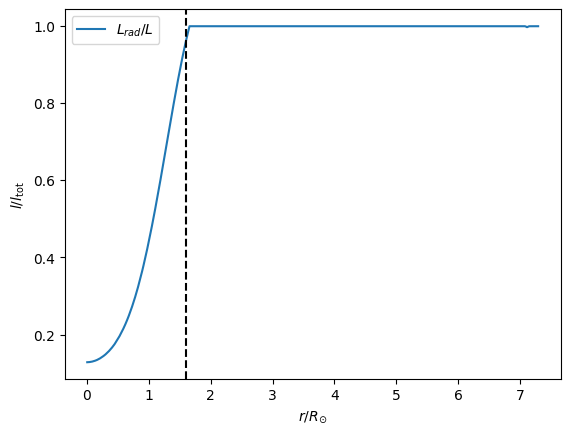

In [5]:
## 1-2 result here
plt.plot(massive_star_ms_radius_cm/rsun_cgs,
         massive_star_ms_lum_rad_cgs/massive_star_ms_lum_cgs,label=r'$L_{rad}/L$')
plt.axvline(1.6,color='k',ls='--')
plt.legend()
plt.xlabel(r'$r/R_{\odot}$')
plt.ylabel(r'$l/l_{\rm{tot}}$')

## 3 result here in words


$\ldots$

## b. Locating the Non-Diffusion Dominated Regime in a Massive star

Using the same MESA data:

1. Next, compute the radial radiative flux ($F_{\rm{rad}}$) and the total convective flux ($F_{\rm{conv}}$) as a function of radius (in units of Rsun) and plot them on the same plot and [**label**](https://www.w3schools.com/python/matplotlib_labels.asp). Normalize both fluxes by their maximum values for comparison using `max()`. Make sure to use cgs!

>Hint: Use our relation for the Flux where $F=l~/4\pi r^2$,

2. On this same plot, again label the approximate location where $F_{\rm{rad}}$ < $F_{\rm{conv}}$ in this case.

This plot suggests we transition from radiation diffusion dominated to convection dominated in the core. 

3. Confirm this result by plotting our opacity $\kappa$ as a function of radius on a seperate plot. On this same plot, compute an analytical estimate for $\kappa_{\rm{es}}$ and $\kappa_{\rm{bf}}$ using the MESA data for $Z$,$\rho$,$T$, etc. 


>Hint:

$$
\kappa_\mathrm{es} = \frac{\sigma_{\rm{e}}}{\mu_{e}m_{u}} = 0.2(1+X)\ \ ,
$$

$$
\kappa_{\rm{bf}}\approx 4.3\times10^{25}(1+X) Z \rho T^{-7/2}
$$



4. Use this plot to determine the dominant source of opacity in the core of a massive star on the main-sequence and **describe** that in a few sentences.

In [6]:
# 1 result here - be sure to convert to CGS before computing the Flux!
massive_star_ms_lum_conv_cgs = massive_star_ms_profile['lum_conv'] * lsun_cgs
massive_star_ms_flux = massive_star_ms_lum_cgs / (4 * np.pi * massive_star_ms_radius_cm**2)
massive_star_ms_flux_rad = massive_star_ms_lum_rad_cgs / (4 * np.pi * massive_star_ms_radius_cm**2)
massive_star_ms_flux_conv = massive_star_ms_lum_conv_cgs / (4 * np.pi * massive_star_ms_radius_cm**2)

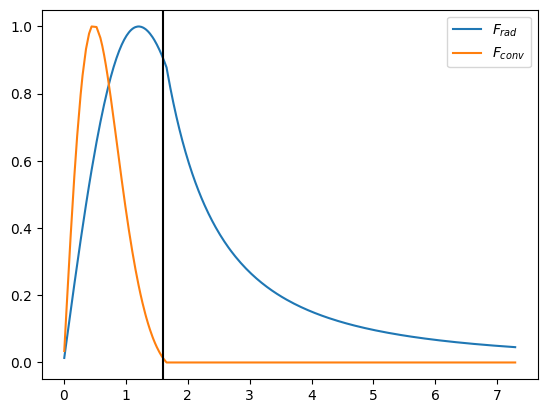

In [7]:
# plot the fluxes here 
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_flux_rad/max(massive_star_ms_flux_rad),label=r'$F_{rad}$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_flux_conv/max(massive_star_ms_flux_conv),label=r'$F_{conv}$')
plt.axvline(1.6,color='k')
plt.legend()

In [8]:
# obtain opacity here
massive_star_ms_kappa = massive_star_ms_profile['opacity']
massive_star_ms_h1 = massive_star_ms_profile['h1']
massive_star_ms_Z = massive_star_ms_profile['z_mass_fraction_metals']
massive_star_ms_logRho = massive_star_ms_profile['logRho']
massive_star_ms_Rho = 10**(massive_star_ms_logRho)
massive_star_ms_logT = massive_star_ms_profile['logT']
massive_star_ms_T = 10**(massive_star_ms_logT)

kappa_bf = 4.3e25 * (1+massive_star_ms_h1)*massive_star_ms_Z*massive_star_ms_Rho*massive_star_ms_T**(-7/2)
kappa_es = 0.2*(1+massive_star_ms_h1)




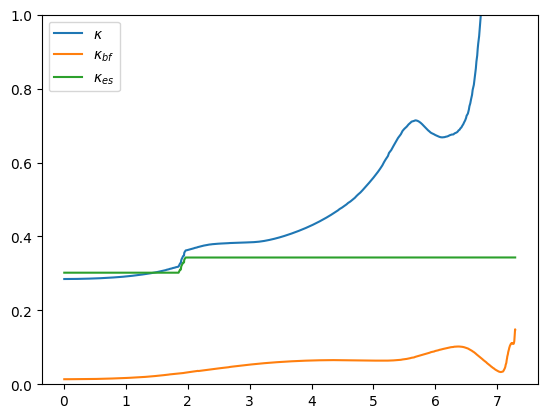

In [9]:
# plot kappa here 
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_kappa,label='$\kappa$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,kappa_bf,label='$\kappa_{bf}$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,kappa_es,label='$\kappa_{es}$')

plt.ylim(0,1)
#plt.axvline(0.70,color='k',ls='--')
#plt.axvline(0.24,color='k',ls='--')
plt.legend()

### b 4 result here in words

$\ldots$

## c. Defining a Core-Boundary in a Massive star

Using the same MESA data:

1. Reproduce your Flux plots from part B.2.

Our goal is to add a few more things to this plot. 

2. Plot the normalized nuclear energy generation as a function of radius (in units of Rsun) on the same plot and label.

3. On the same plot, plot the normalized convective velocity `conv_vel`.

4. Then, use that to determine the approximate location where $\epsilon_{\rm{nuc,normalized}}\rightarrow0$, we will define this as the edge of the hydrogen burning core. 

5. Lastly, annotate the three regions on the same plot, 'core', 'radiative', and 'convective' using annotate.


In [10]:
# obtain eps nuc
massive_star_ms_eps_nuc = massive_star_ms_profile['eps_nuc']
massive_star_ms_conv_vel = massive_star_ms_profile['conv_vel']

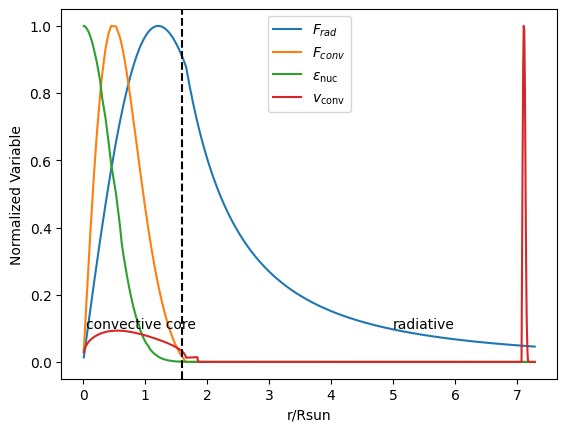

In [11]:

# plot everything combined and annotated
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_flux_rad/max(massive_star_ms_flux_rad),label=r'$F_{rad}$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_flux_conv/max(massive_star_ms_flux_conv),label=r'$F_{conv}$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_eps_nuc/max(massive_star_ms_eps_nuc),label=r'$\epsilon_{\rm{nuc}}$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_conv_vel/max(massive_star_ms_conv_vel),label=r'$v_{\rm{conv}}$')
plt.axvline(1.6,color='k',ls='--')
plt.annotate('convective core',xy=(0.05,0.1))
plt.annotate('radiative',xy=(5,0.1))
plt.ylabel('Normalized Variable')
plt.xlabel('r/Rsun')
plt.legend()

## d. (Bonus) Locating the Non-Diffusion Dominated Regime in a Solar-like star

Using the same MESA data from the last class: 


* **New** $1.0 M_{\odot}$ Main-Sequence _profile_ data: [1m_pre_ms_to_wd.data](data/1m_pre_ms_to_wd.data);

1. Plot opacity $\kappa$ as a function of radius on a seperate plot. On this same plot, compute an analytical estimate for $\kappa_{\rm{es}}$ and $\kappa_{\rm{bf}}$, and $\kappa_{\rm{ff}}$ using the MESA data for $Z$,$\rho$,$T$, etc. 


>Hint:

$$
\kappa_\mathrm{es} = \frac{\sigma_{\rm{e}}}{\mu_{e}m_{u}} = 0.2(1+X)\ \ ,
$$

$$
\kappa_{\rm{bf}}\approx 4.3\times10^{25}(1+X) Z \rho T^{-7/2}
$$

$$
\kappa_{\rm{ff}}\propto \rho T^{-7/2} \approx 3.8\times10^{22}(1+X)\rho T^{-7/2}
$$



> Hint: use `plt.ylim(0,30)` to zoom in.


2. Use this plot to determine the dominant source of opacity in a solar-like star.


In [12]:
massive_star_ms_profile = pd.read_csv('data/1m_pre_ms_to_wd.data',sep=r'\s+',header=4)

In [13]:
# obtain opacity here
massive_star_ms_radius_cm = massive_star_ms_profile['radius_cm']
massive_star_ms_kappa = massive_star_ms_profile['opacity']
massive_star_ms_h1 = massive_star_ms_profile['h1']
massive_star_ms_Z = massive_star_ms_profile['z_mass_fraction_metals']
massive_star_ms_logRho = massive_star_ms_profile['logRho']
massive_star_ms_Rho = 10**(massive_star_ms_logRho)
massive_star_ms_logT = massive_star_ms_profile['logT']
massive_star_ms_T = 10**(massive_star_ms_logT)

kappa_bf = 4.3e25 * (1+massive_star_ms_h1)*massive_star_ms_Z*massive_star_ms_Rho*massive_star_ms_T**(-7/2)
kappa_ff = 3.8e22 * (1+massive_star_ms_h1)*massive_star_ms_Z*massive_star_ms_Rho*massive_star_ms_T**(-7/2)
kappa_es = 0.2*(1+massive_star_ms_h1)


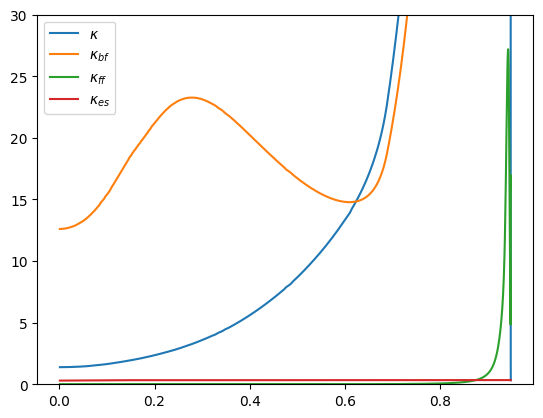

In [14]:
# plot kappa here 
plt.plot(massive_star_ms_radius_cm/rsun_cgs,massive_star_ms_kappa,label='$\kappa$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,kappa_bf,label='$\kappa_{bf}$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,kappa_ff,label='$\kappa_{ff}$')
plt.plot(massive_star_ms_radius_cm/rsun_cgs,kappa_es,label='$\kappa_{es}$')

plt.ylim(0,30)
#plt.axvline(0.70,color='k',ls='--')
#plt.axvline(0.24,color='k',ls='--')
plt.legend()